In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px
import inspect
import time
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import acf, pacf
%matplotlib inline

In [2]:
df = pd.read_csv('E:\Document\PROJECT_1\data\hanoi-aqi-weather-data.csv')
df['Local Time'] = pd.to_datetime(df['Local Time'])
df.set_index('Local Time', inplace=True)
df.head()

,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
Local Time,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,2022-12-31T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,87,0.0,1024,73,14.8,0.0,0.66
2023-01-01 01:00:00,2022-12-31T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,87,0.0,1023,75,14.6,0.0,1.00
2023-01-01 02:00:00,2022-12-31T19:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,58.0,83,0.0,1023,79,14.3,0.0,1.00
2023-01-01 03:00:00,2022-12-31T20:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.0,57.0,79,0.0,1023,82,14.1,0.0,1.00
2023-01-01 04:00:00,2022-12-31T21:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.0,56.0,75,0.0,1022,86,13.8,0.0,1.00


In [3]:
df_pm25_hourly = df[['PM25']].copy()
df_pm25_daily = df_pm25_hourly.resample('D')['PM25'].agg('mean')
df_pm25 = df_pm25_daily
df_pm25

Local Time
2023-01-01     71.541667
2023-01-02     90.375000
2023-01-03     65.916667
2023-01-04     97.166667
2023-01-05     72.500000
                 ...    
2024-12-27     49.958333
2024-12-28     44.167083
2024-12-29     78.597083
2024-12-30    100.277917
2024-12-31     86.299500
Freq: D, Name: PM25, Length: 731, dtype: float64

In [4]:
df_pm25.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 731 entries, 2023-01-01 to 2024-12-31
Freq: D
Series name: PM25
Non-Null Count  Dtype  
--------------  -----  
731 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB


In [5]:
adf_result = adfuller(df_pm25)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -6.5148641359401935
p-value: 1.0776256378814557e-08
Critical Values: {'1%': -3.4393644334758475, '5%': -2.8655182850048306, '10%': -2.568888486973192}


<Axes: title={'center': 'Hanoi PM2.5 Levels, Daily Data'}, xlabel='Date', ylabel='PM2.5 Level'>

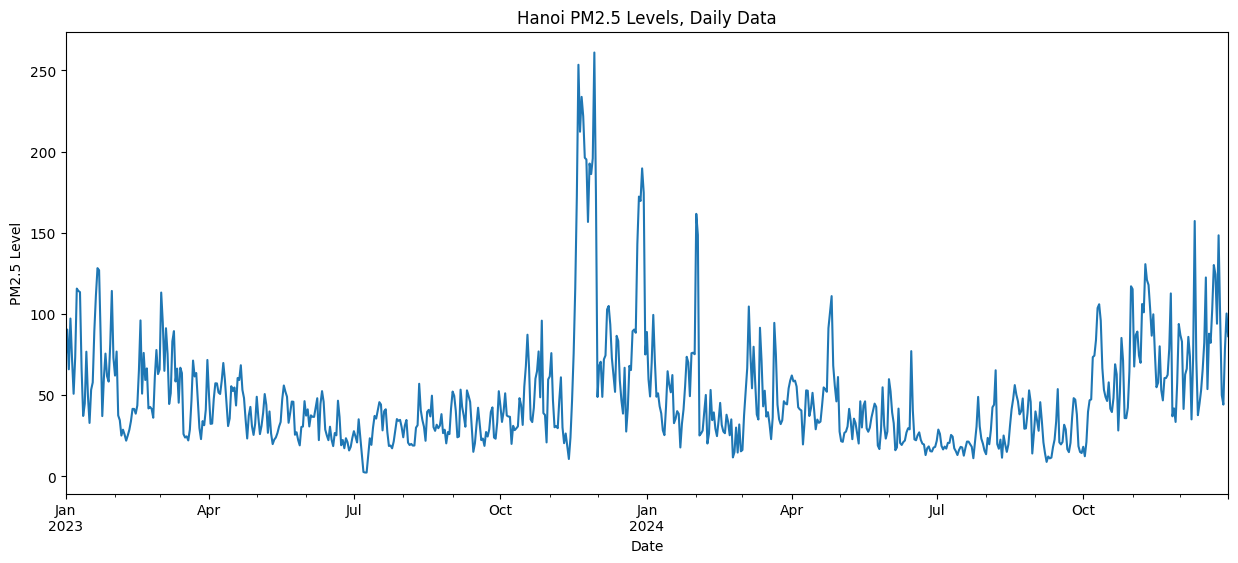

In [6]:

fig, ax = plt.subplots(figsize=(15, 6))
df_pm25.plot(xlabel = "Date",ylabel= "PM2.5 Level",
                           title= "Hanoi PM2.5 Levels, Daily Data", ax=ax)

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, ACF')

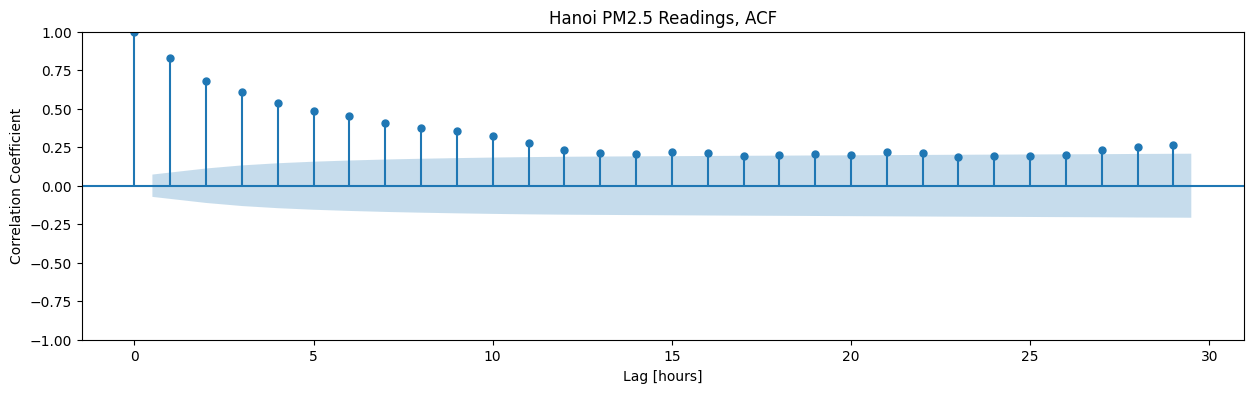

In [7]:

fig, ax = plt.subplots(figsize=(15, 4))
plot_acf(df_pm25, ax=ax)
plt.xlabel("Lag [days]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, ACF")

In [8]:
# Tính toán giá trị ACF
acf_values = acf(df_pm25, nlags=30)
print("ACF Values:")
print(acf_values)
print()

ACF Values:
[1.         0.8318345  0.68120999 0.6071318  0.54026892 0.48526443
 0.4505717  0.40567924 0.37353712 0.35317632 0.32204188 0.27875251
 0.23205856 0.2097161  0.20668477 0.21699742 0.20990811 0.19037557
 0.20192397 0.2048931  0.200617   0.21692296 0.21362843 0.18756037
 0.1902888  0.19382632 0.20020349 0.23104868 0.25152455 0.26508183
 0.29204193]



**-> KẾT LUẬN:** Từ biểu đồ, chuỗi có tự tương quan mạnh ở các độ trễ (lag 1-5) -> giá trị Pm2.5 hôm nay ảnh hưởng mạnh ở các ngày trước đó. Chưa thể kết luận đc giá trị q

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, PACF')

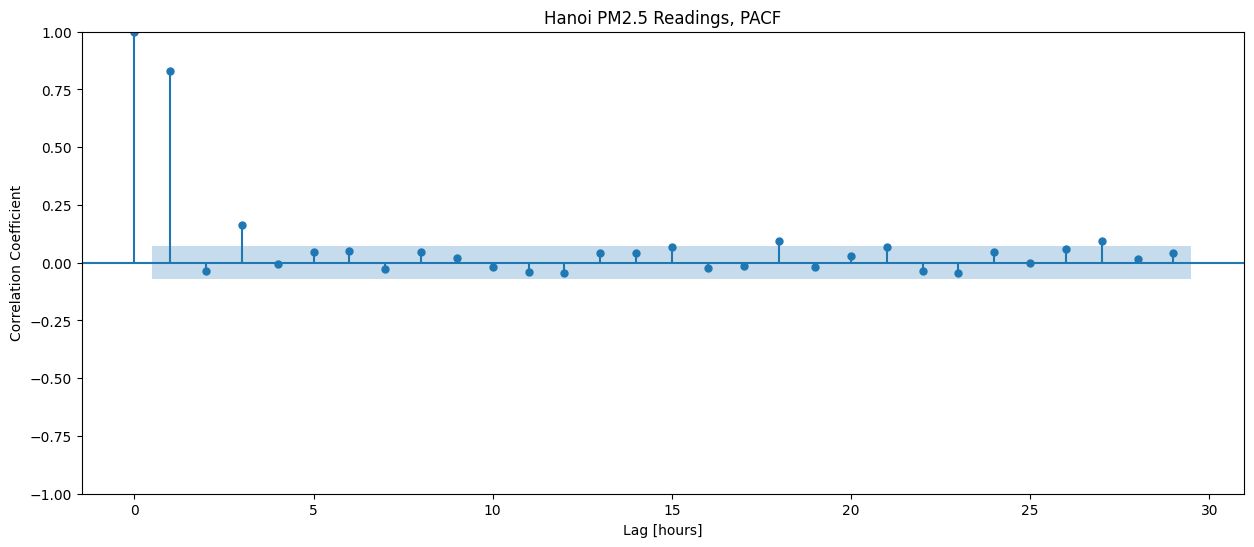

In [9]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(df_pm25, ax=ax)
plt.xlabel("Lag [days]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, PACF")

In [10]:
# Tính toán giá trị PACF
pacf_values = pacf(df_pm25, nlags=30)
print("PACF Values:")
print(pacf_values)

PACF Values:
[ 1.00000000e+00  8.32973997e-01 -3.51678932e-02  1.63291732e-01
 -5.85967474e-03  4.81100217e-02  4.97739613e-02 -2.55543469e-02
  4.72872127e-02  2.24349446e-02 -1.76001063e-02 -4.02010456e-02
 -4.57013655e-02  4.52583172e-02  4.27404266e-02  6.95492475e-02
 -2.20388165e-02 -1.49361272e-02  9.62861783e-02 -1.84846989e-02
  2.92705834e-02  7.25379651e-02 -3.54955336e-02 -4.40180356e-02
  4.89532070e-02  1.75789400e-04  6.04765775e-02  1.00863504e-01
  1.83581470e-02  4.40824720e-02  7.35591644e-02]


Biểu đồ PACF của chuỗi PM2.5 cho thấy hai độ trễ đầu (lag 1 và lag 2) có giá trị tương quan riêng phần rất cao và vượt ra ngoài vùng tin cậy, trong khi các độ trễ còn lại đều nằm trong phạm vi tin cậy và dao động quanh 0. Điều này cho thấy thành phần AR trong mô hình nên có bậc p = 2. Việc PACF “cắt cụt” sau lag 2 là đặc điểm điển hình của mô hình AR(2).

In [11]:
int(len(df_pm25))*0.8

584.8000000000001

In [12]:
cutoff_test = int(len(df_pm25)* 0.8) 
df_pm25_train = df_pm25.iloc[:cutoff_test]
df_pm25_test = df_pm25.iloc[cutoff_test:]
print("df_pm25_train shape:", df_pm25_train.shape)
print("df_pm25_test shape:", df_pm25_test.shape)

df_pm25_train shape: (584,)
df_pm25_test shape: (147,)


In [13]:
# Perform ADF test
adf_result = adfuller(df_pm25_train)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -5.830512605524053
p-value: 3.985322860994825e-07
Critical Values: {'1%': -3.4416553818946145, '5%': -2.8665274458710064, '10%': -2.5694261699959413}


In [14]:
# 1. Tính giá trị trung bình của tập huấn luyện (training set)
df_pm25_train_mean = df_pm25_train.mean()

# 2. Tạo một danh sách dự đoán. 
#    Mô hình cơ sở này chỉ dự đoán "giá trị trung bình" lặp đi lặp lại.
#    Số lần dự đoán bằng đúng số lượng dữ liệu trong tập kiểm thử (test set).
df_pm25_pred_baseline = [df_pm25_train_mean] * len(df_pm25_test)

# 3. Tính Lỗi tuyệt đối trung bình (MAE) của mô hình cơ sở
#    Bằng cách so sánh dữ liệu "thực tế" (df_pm25_test) 
#    với dữ liệu "dự đoán" (df_pm25_pred_baseline)
mae_baseline = mean_absolute_error(df_pm25_test, df_pm25_pred_baseline)

# 4. In ra giá trị PM2.5 trung bình (đã làm tròn 2 chữ số)
print("Giá trị PM2.5 trung bình:", round(df_pm25_train_mean, 2))

# 5. In ra MAE của mô hình cơ sở (đã làm tròn 2 chữ số)
print("MAE của mô hình cơ sở (Baseline MAE):", round(mae_baseline, 2))

Giá trị PM2.5 trung bình: 47.51
MAE của mô hình cơ sở (Baseline MAE): 26.12


Mô hình cơ sở của bạn đoán: "Tôi đoán mọi ngày đều là 47.51."

Kết quả là: "Cách đoán đó, trung bình, đã sai 22.86."

MAE: Lỗi tuyệt đối trung bình (Mean Absolute Error)
- Trung bình các dự đoán sai lệch bao niêu so với thực tế
B1: Tính Lỗi (Error) Thưc tế - dự đoan
b2: Lỗi tuyệt đối: Trị tuyệt đối các giá trị tính ở B1
B3: Cộng tất cả chia trung bình

Nhận xét:
- Baseline = "Dự doán bằng giá trị trung bình"

In [15]:
p_params = range(0, 8, 1)
q_params = range(0, 3, 1)
list(p_params)

[0, 1, 2, 3, 4, 5, 6, 7]

[Dẫn chứng về tính chu kỳ của Pm25](https://www.sciencedirect.com/science/article/pii/S1309104215305456)

In [16]:
mae_grid = {}          # {p: [MAE(q0), MAE(q1), ...]}
aic_grid = {}          # {p: [AIC(q0), AIC(q1), ...]}
best = {"order": None, "MAE": float("inf"), "AIC": float("inf")}

for p in p_params:
    mae_grid[p] = []
    aic_grid[p] = []
    for q in q_params:
        order = (p, 0, q)   # d = 0 vì ADF cho thấy dừng
        try:
            t0 = time.time()
            model = ARIMA(
                df_pm25_train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()
            elapsed = round(time.time() - t0, 2)
            print(f"Trained ARIMA{order} in {elapsed}s (AIC={model.aic:.2f}).")

            # In-sample prediction - dùng fittedvalues an toàn hơn
            yhat = model.fittedvalues

            mae = mean_absolute_error(df_pm25_train[len(df_pm25_train) - len(yhat):], yhat)
            mae_grid[p].append(mae)
            aic_grid[p].append(model.aic)

            # Cập nhật best theo AIC (khuyến nghị)
            if model.aic < best["AIC"]:
                best = {"order": order, "MAE": mae, "AIC": model.aic}

        except Exception as e:
            print(f"Skip ARIMA{order}: {e}")
            mae_grid[p].append(None)
            aic_grid[p].append(None)

print("\n" + "="*50)
print("Best model by AIC:", best)
print("="*50)
print("\nMAE grid:", mae_grid)
print("\nAIC grid:", aic_grid)

Trained ARIMA(0, 0, 0) in 0.08s (AIC=5808.19).
Trained ARIMA(0, 0, 1) in 0.07s (AIC=5353.32).
Trained ARIMA(0, 0, 2) in 0.08s (AIC=5203.53).
Trained ARIMA(1, 0, 0) in 0.02s (AIC=5065.06).
Trained ARIMA(1, 0, 1) in 0.06s (AIC=5055.39).
Trained ARIMA(1, 0, 2) in 0.07s (AIC=5036.22).
Trained ARIMA(2, 0, 0) in 0.02s (AIC=5056.38).
Trained ARIMA(2, 0, 1) in 0.17s (AIC=5048.42).
Trained ARIMA(2, 0, 2) in 0.13s (AIC=5037.66).
Trained ARIMA(3, 0, 0) in 0.03s (AIC=5038.84).
Trained ARIMA(3, 0, 1) in 0.1s (AIC=5037.30).
Trained ARIMA(3, 0, 2) in 0.37s (AIC=5031.82).
Trained ARIMA(4, 0, 0) in 0.03s (AIC=5027.83).
Trained ARIMA(4, 0, 1) in 0.12s (AIC=5028.57).
Trained ARIMA(4, 0, 2) in 0.45s (AIC=5025.62).
Trained ARIMA(5, 0, 0) in 0.05s (AIC=5018.94).
Trained ARIMA(5, 0, 1) in 0.28s (AIC=5020.33).
Trained ARIMA(5, 0, 2) in 0.42s (AIC=5019.42).
Trained ARIMA(6, 0, 0) in 0.05s (AIC=5011.45).
Trained ARIMA(6, 0, 1) in 0.21s (AIC=5012.51).
Trained ARIMA(6, 0, 2) in 0.3s (AIC=5014.51).
Trained ARIMA(7

In [17]:
# Sau khi chạy grid search
mae_df = pd.DataFrame(mae_grid)
aic_df = pd.DataFrame(aic_grid)

print("\nMAE Grid:")
print(mae_df.round(2))
print("\nAIC Grid:")
print(aic_df.round(2))




MAE Grid:
       0      1      2      3      4      5      6      7
0  22.84  12.49  12.49  12.33  12.36  12.33  12.30  12.29
1  16.30  12.50  12.43  12.35  12.34  12.33  12.24  12.25
2  14.40  12.33  12.35  12.39  12.48  12.37  12.24  12.44

AIC Grid:
         0        1        2        3        4        5        6        7
0  5808.19  5065.06  5056.38  5038.84  5027.83  5018.94  5011.45  5004.41
1  5353.32  5055.39  5048.42  5037.30  5028.57  5020.33  5012.51  5006.42
2  5203.53  5036.22  5037.66  5031.82  5025.62  5019.42  5014.51  4996.70


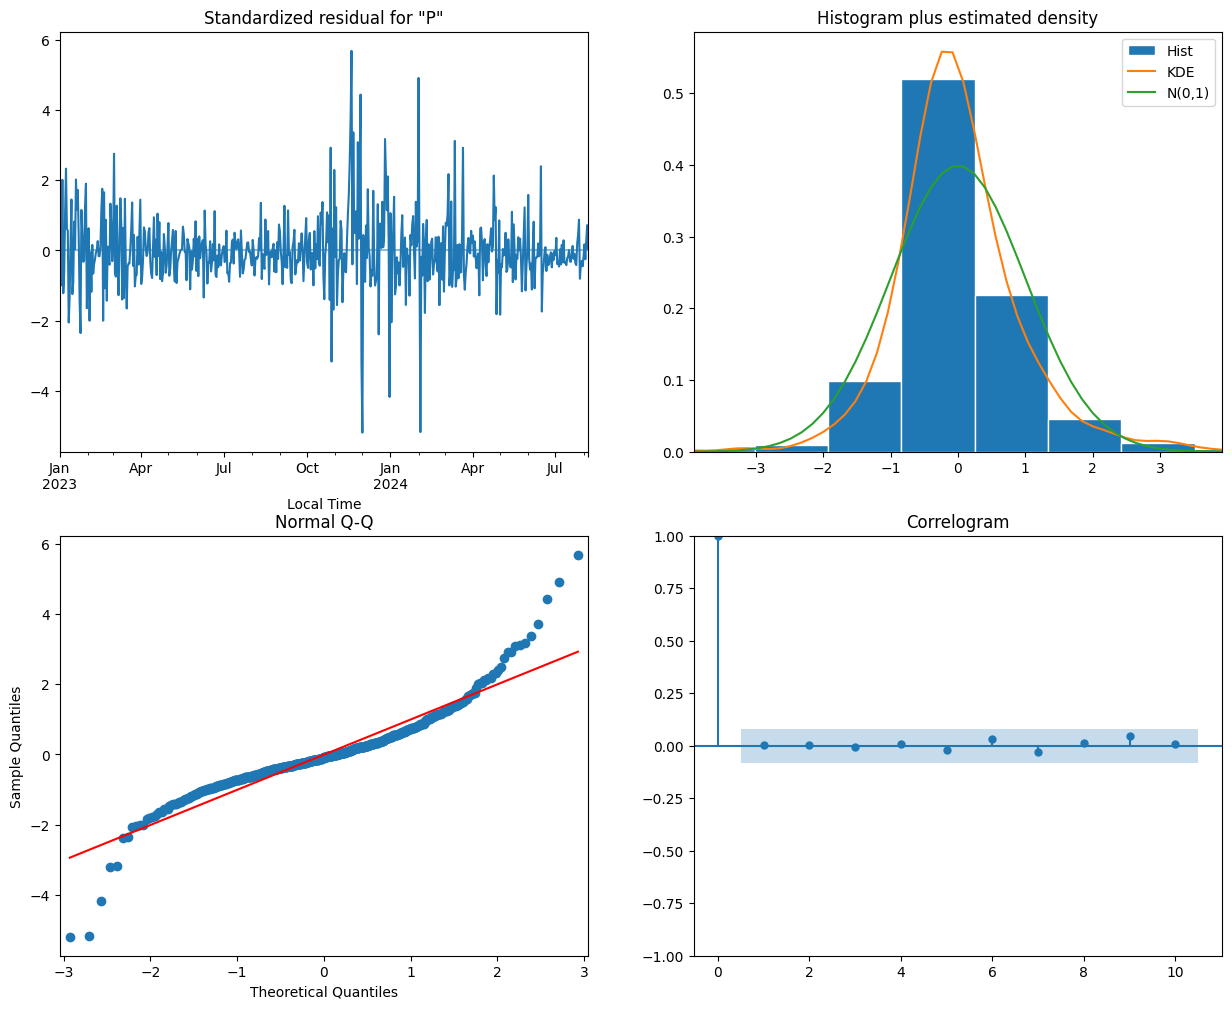

In [18]:
model = ARIMA(df_pm25_train, order=(7,0,2))
results = model.fit()
results.plot_diagnostics(figsize=(15,12))
plt.show()



In [19]:
df_pm25_pred_wfv = pd.Series()
history = df_pm25_train.copy()
for i in range(len(df_pm25_test)):
    model = ARIMA(history, order = (7, 0, 2)).fit()
    next_pred = model.forecast()
    df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])
    df_pm25_pred_wfv = df_pm25_pred_wfv.round(2)
    history = pd.concat([history, df_pm25_test[next_pred.index]])

C:\Users\hungd\AppData\Local\Temp\ipykernel_10816\776910693.py:6: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])


In [21]:
df_pm25_pred_wfv

2024-08-07    39.45
2024-08-08    64.87
2024-08-09    14.50
2024-08-10    28.84
2024-08-11    20.25
              ...  
2024-12-27    80.05
2024-12-28    64.12
2024-12-29    48.66
2024-12-30    75.99
2024-12-31    91.99
Freq: D, Length: 147, dtype: float64

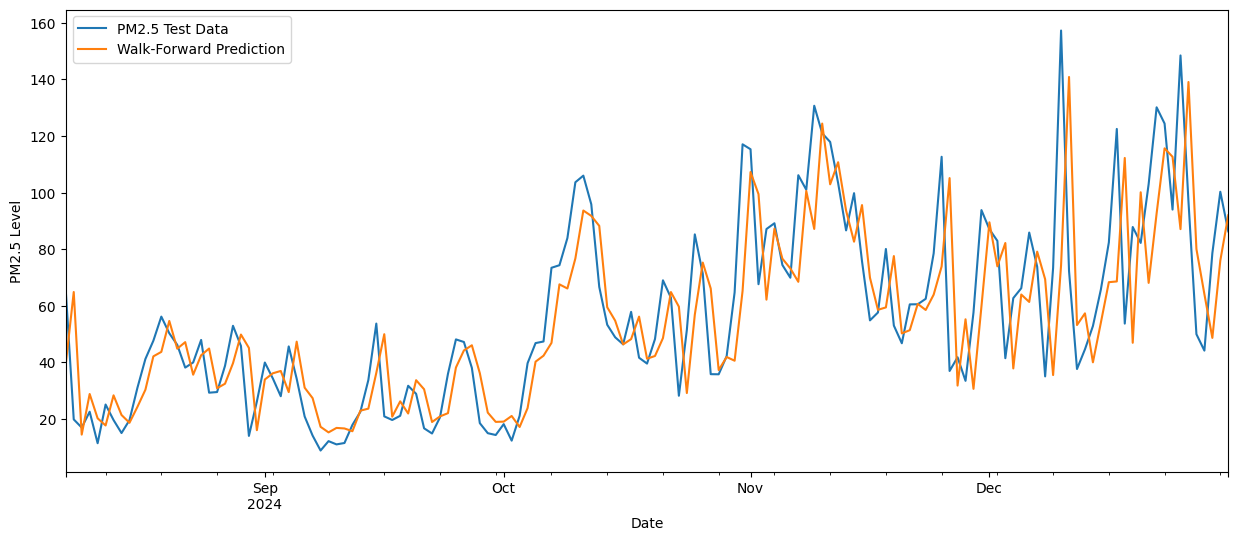

In [22]:
ax = df_pm25_test.plot(label = 'PM2.5 Test Data', figsize=(15, 6))
df_pm25_pred_wfv.plot(ax=ax, label='Walk-Forward Prediction')
plt.ylabel('PM2.5 Level')
plt.xlabel('Date')
plt.legend()
plt.show()

In [23]:
# Đọc file test
df_test = pd.read_csv(r"E:\Document\PROJECT_1\data\data_test.csv")

# Chuẩn hóa cột thời gian
df_test['Local Time'] = pd.to_datetime(df_test['Local Time'])
df_test = df_test.set_index('Local Time').sort_index()

# Lấy cột PM2.5, trung bình theo ngày, nội suy giá trị thiếu
df_pm25_test = df_test[['PM25']].resample('D').mean().asfreq('D').interpolate()

df_pm25_test.shape

(304, 1)

In [26]:
y_train = df_pm25.astype(float)
y_test  = df_pm25_test.astype(float)

y_pred = []

history = y_train.copy()

for i in range(len(y_test)):
    model = ARIMA(history, order=(7,0,2),
                  enforce_stationarity=False,
                  enforce_invertibility=False).fit()
    
    next_fc = model.forecast(steps=1)
    y_pred.append(float(next_fc.iloc[0]))

    history = pd.concat([history, y_test.iloc[i:i+1]])

# Convert sang Series với đúng index
y_pred = pd.Series(y_pred, index=y_test.index)


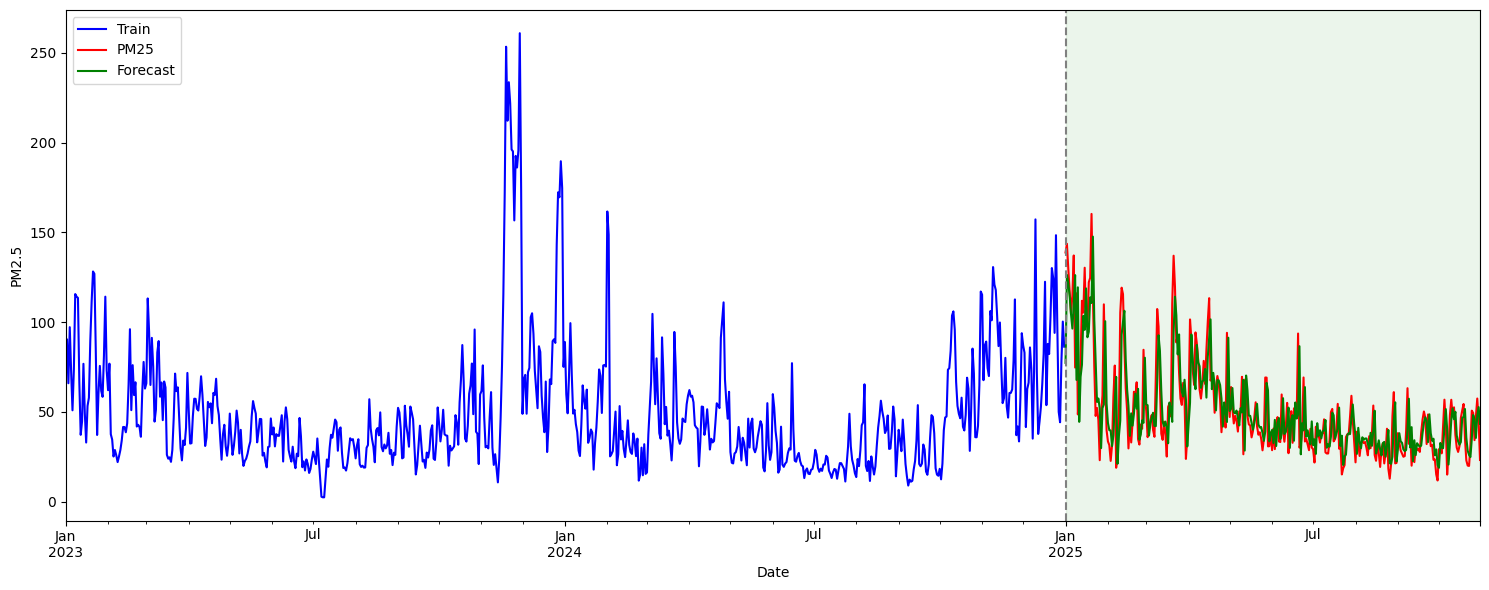

In [27]:
# vẽ
ax = y_train.plot(label='Train', figsize=(15,6), color='blue')
y_test.plot(ax=ax, label='Test', color='red')
y_pred.plot(ax=ax, label='Forecast', color='green')
ax.axvline(y_test.index[0], ls='--', c='gray')
ax.axvspan(y_test.index[0], y_test.index[-1], color='green', alpha=0.08)
ax.set_ylabel('PM2.5'); ax.set_xlabel('Date'); ax.legend(); plt.tight_layout(); plt.show()

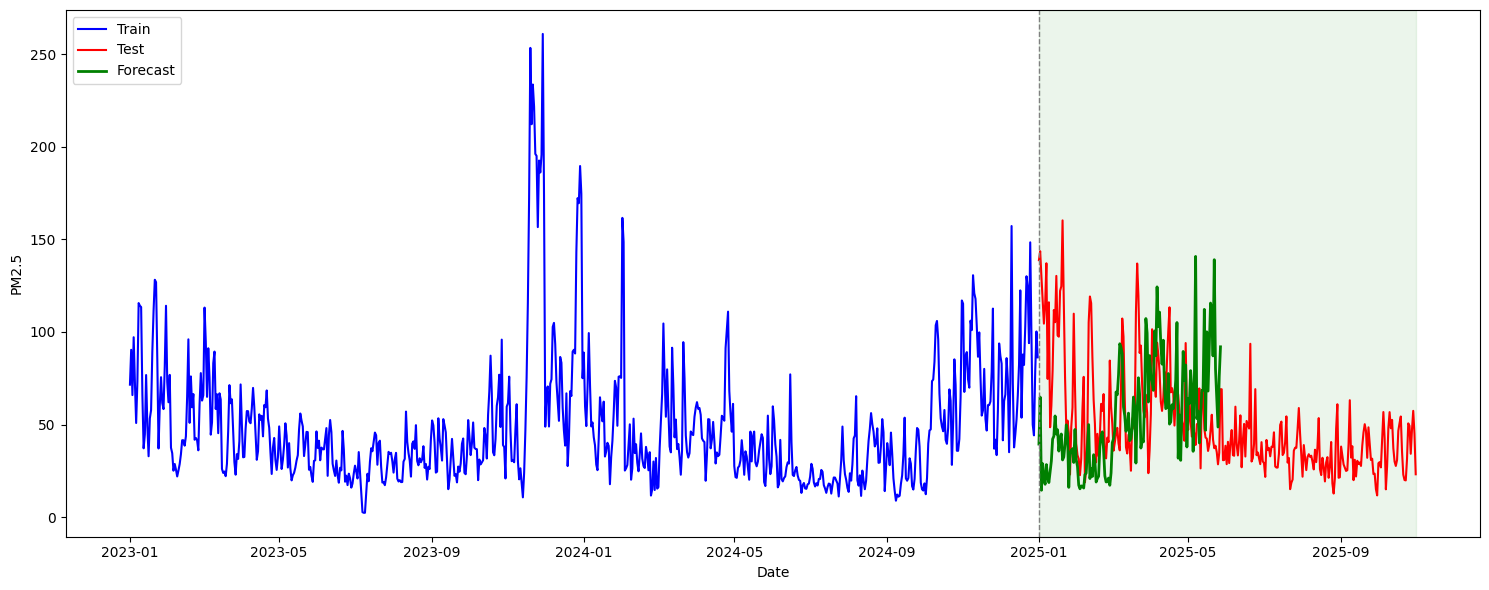

In [28]:
plt.figure(figsize=(15,6))
ax = plt.gca() 

# --- PLOT TRAIN ---
ax.plot(df_pm25.index, df_pm25.values, label='Train', color='blue', linewidth=1.5)
# --- PLOT TEST ---
ax.plot(df_pm25_test.index, df_pm25_test.values,label='Test', color='red', linewidth=1.5)
        
df_pm25_pred_wfv = df_pm25_pred_wfv.copy()
df_pm25_pred_wfv.index = df_pm25_test.index[:len(df_pm25_pred_wfv)]

# --- PLOT FORECAST ---
ax.plot(df_pm25_pred_wfv.index, df_pm25_pred_wfv.values, label='Forecast', color='green', linewidth=2)
      

# --- Gạch đường phân cách Train/Test ---
split = df_pm25_test.index[0]
ax.axvline(split, color='gray', linestyle='--', linewidth=1)

# --- Tô màu vùng Test ---
ax.axvspan(df_pm25_test.index[0],
           df_pm25_test.index[-1],
           color='green', alpha=0.08)

# --- Custom ---
# plt.title(f"ARIMA(7,0,2) - Walk-Forward Forecast\nTest MAE = {mae_wfv:.2f}",
#           fontsize=14)
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
mae_wfv = mean_absolute_error(y_test, y_pred)
print("WFV MAE (2025):", round(mae_wfv, 2))
mse_wfv = mean_squared_error(y_test, y_pred)
print(f'MSE {mse_wfv}') ######

WFV MAE (2025): 12.94
MSE 329.1729319574622


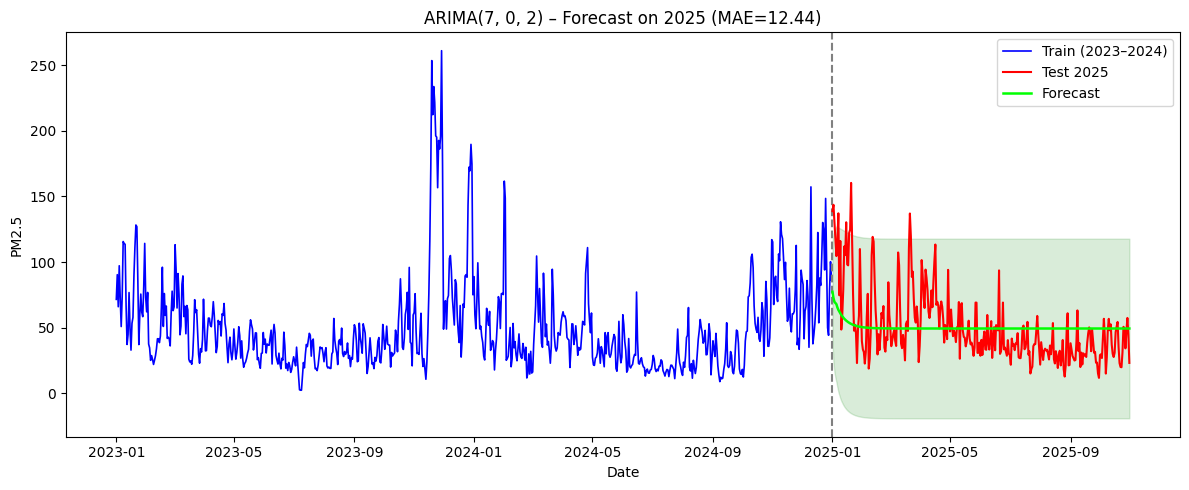

In [30]:
hist = df_pm25.copy()
test = df_pm25_test.copy()
best_order = (7, 0, 2)

best_order = (7, 0, 2)
model = ARIMA(hist, order=best_order,
              enforce_stationarity=False,
              enforce_invertibility=False).fit()

# 3) Dự báo đúng độ dài test 2025
steps = len(test)
fc = model.get_forecast(steps=steps)
y_pred = pd.Series(fc.predicted_mean, index=test.index)
ci = fc.conf_int(alpha=0.05)
ci.index = test.index


# 5) Vẽ
plt.figure(figsize=(12,5))
plt.plot(hist.index, hist.values, label='Train (2023–2024)', color='blue', linewidth=1.2)
plt.axvline(test.index[0], color='gray', ls='--')
plt.plot(test.index, test.values, label='Test 2025', color='red', linewidth=1.5)
plt.plot(y_pred.index, y_pred.values, label='Forecast', color='lime', linewidth=1.8)
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color='green', alpha=0.15)
plt.title(f"ARIMA{best_order} – Forecast on 2025 (MAE={mae:.2f})")
plt.xlabel("Date"); plt.ylabel("PM2.5"); plt.legend(); plt.tight_layout(); plt.show()


In [31]:

# 4) Đánh giá
mae = mean_absolute_error(test, y_pred)
print("Official 2025 MAE:", round(mae, 2))
mse = mean_squared_error(test, y_pred)
print(f'MSE: {mse}')

Official 2025 MAE: 19.51
MSE: 670.6900401614326


## Kiểm tra yếu tố mùa vụ